# STEP 1 — Load & Transform Dataset

## Imports

In [511]:
import nltk
import re
import json
import os
import numpy as np
import pandas as pd
import torch
from nltk.corpus import stopwords
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import Concatenate
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Embedding, LSTM, Dense, Bidirectional, Dropout
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Activation, RepeatVector, Lambda
# nltk.download('punkt')
# nltk.download('punkt_tab')
# nltk.download('stopwords')

## Parse JSON Files

In [512]:
def load_dataset(path):
    dataset = []
    
    for file in os.listdir(path):
        if file.endswith(".json"):
            file_path = os.path.join(path, file)
            
            with open(file_path, encoding="utf-8") as f:
                data = json.load(f)

                for article in data.get("data", []):
                    for para in article.get("paragraphs", []):
                        context = para.get("context", "")

                        for qa in para.get("qas", []):
                            question = qa.get("question", "")
                            answers = qa.get("answers", [])

                            if answers:
                                answer = answers[0].get("text", "")
                                
                                dataset.append({
                                    "question": question,
                                    "context": context,
                                    "answer": answer
                                })
    
    return dataset
    

## Inspect Data

In [513]:
data = load_dataset("data")

print(f"\nTotal examples loaded: {len(data)}")
if data:
    print("\nFirst example:")
    print(json.dumps(data[0], indent=2, ensure_ascii=False))


Total examples loaded: 240

First example:
{
  "question": "ما الحدث الذي جعل أورسون ويلز مشهورًا قبل دخوله السينما؟",
  "context": "في ليلة 30 أكتوبر 1938، انقطع بث إذاعي ليعلن عن غزو فضائي في نيوجيرسي. تسبب ذلك في ذعر واسع لأن الناس صدقوا الخبر. لاحقًا تبيّن أن الحدث كان تمثيلية إذاعية من إخراج أورسون ويلز. هذه التجربة أثبتت قدرته على التأثير في الجمهور.",
  "answer": "تمثيلية إذاعية عن غزو فضائي"
}


# STEP 2 — Preprocessing

## Cleaning

In [514]:
# def remove_stopwords_and_punctuation_from_text(text):
#     nltk_stop_words = set(stopwords.words('arabic'))


#     # punctuation ='!"$%&()*,-./:;<=>?@[\\]^_`{|}~'
#     punctuation = [
#     "،","؛","؟","ـ","«","»","‹","›","“","”","‘","’",
#     ".",",",";",":","!","?","-","_","(",")","[","]","{","}",
#     "\"","'","/","\\","|","@","#","$","%","^","&","*","+","=","<",">","~","`","``","''"
#     ]
#     for p in punctuation:
#         text = text.replace(p, '')

#     tokens = nltk.word_tokenize(text)

#     filtered_tokens = [
#         word for word in tokens 
#         if word not in nltk_stop_words 
#         and not re.search(r'[a-zA-Z]', word)]   # remove words containing English letters
#     # Join the tokens back into a string
#     filtered_text = ' '.join(filtered_tokens)
#     return filtered_text

In [515]:
# for item in data:
#     item['question'] = remove_stopwords_and_punctuation_from_text(item['question'])
#     item['context'] = remove_stopwords_and_punctuation_from_text(item['context'])
#     item['answer'] = remove_stopwords_and_punctuation_from_text(item['answer'])

## Normalization

In [516]:
def normalize_text(text):
    
    # 1. Convert English letters to lowercase
    text = text.lower()
    
    # 2. Remove Arabic Tashkeel (diacritics)
    tashkeel = r'[\u0617-\u061A\u064B-\u0652]'
    text = re.sub(tashkeel, '', text)

    # 3. Normalize Arabic letters
    text = re.sub("[إأآا]", "ا", text)
    text = re.sub("ى", "ي", text)
    text = re.sub("ة", "ه", text)
    text = re.sub("گ", "ك", text)

    # 4. Remove Tatweel (ـ)
    text = re.sub("ـ", "", text)

    return text

In [517]:
for item in data:
    item['question'] = normalize_text(item['question'])
    item['context'] = normalize_text(item['context'])
    item['answer'] = normalize_text(item['answer'])

# STEP 3 — Tokenization

## Tokenize

### Approach 1

In [518]:
# def tokenize(text):
#     return text.split()

### Approach 2

In [519]:
tokenizer = Tokenizer(
    num_words=2390,
    split=' ',
    char_level=False,
    oov_token="<OOV>"
  )

In [520]:
all_texts = []

for item in data:
    all_texts.append(item['question'])
    all_texts.append(item['context'])
    all_texts.append(item['answer'])

all_texts = [text for text in all_texts if text and isinstance(text, str)]
tokenizer.fit_on_texts(all_texts)

In [521]:
vocab_list = tokenizer.word_index
print(len(vocab_list))

2381


## Encode Text

### Approach 1

In [522]:
# def encode(text, vocab, max_len=100):
#     tokens = tokenize(text)
#     ids = [vocab.get(t, vocab["<unk>"]) for t in tokens]

#     # padding
#     ids = ids[:max_len]
#     ids += [vocab["<pad>"]] * (max_len - len(ids))

#     return ids

In [523]:
# ### Encode the dataset with answers also encoded
# encoded_data = []
# for item in data:
#     encoded_item = {
#         "question": encode(item["question"], vocab),
#         "context": encode(item["context"], vocab),
#         "answer": encode(item["answer"], vocab)
#     }
#     encoded_data.append(encoded_item)


### Approach 2

In [524]:
# max_question_len = 0
# max_context_len = 0
# max_answer_len = 0

# for item in data:
#     q_tokens = len(tokenizer.texts_to_sequences([item['question']])[0]) if 'question' in item else 0
#     c_tokens = len(tokenizer.texts_to_sequences([item['context']])[0])  if 'context' in item else 0
#     a_tokens = len(tokenizer.texts_to_sequences([item['answer']])[0])    if 'answer' in item else 0
    
#     max_question_len = max(max_question_len, q_tokens)
#     max_context_len  = max(max_context_len, c_tokens)
#     max_answer_len   = max(max_answer_len, a_tokens)

# print(f"Maximum Question Length: {max_question_len} tokens")
# print(f"Maximum Context Length : {max_context_len} tokens")
# print(f"Maximum Answer Length  : {max_answer_len} tokens")

In [525]:
lengths = [len(item['question']) for item in data]
print("input_sequences lengths:")
print("max:", np.max(lengths))
print("min:", np.min(lengths))
print("95 percentile:", np.percentile(lengths,95))
print("90 percentile:", np.percentile(lengths,90))

lengths = [len(item['answer']) for item in data]
print("answer_sequences lengths:")
print("max:", np.max(lengths))
print("min:", np.min(lengths))
print("95 percentile:", np.percentile(lengths,95))
print("90 percentile:", np.percentile(lengths,90))

lengths = [len(item['context']) for item in data]
print("context_sequences lengths:")
print("max:", np.max(lengths))
print("min:", np.min(lengths))
print("95 percentile:", np.percentile(lengths,95))
print("90 percentile:", np.percentile(lengths,90))

input_sequences lengths:
max: 73
min: 14
95 percentile: 59.0
90 percentile: 54.099999999999994
answer_sequences lengths:
max: 66
min: 4
95 percentile: 50.0
90 percentile: 45.0
context_sequences lengths:
max: 261
min: 16
95 percentile: 169.04999999999998
90 percentile: 135.2


In [526]:
MAX_Q_LEN = 100
MAX_C_LEN = 200
MAX_A_LEN = 70

q_seq = []
c_seq = []
a_seq = []

for item in data:
    q_seq.append(tokenizer.texts_to_sequences([item['question']])[0])
    c_seq.append(tokenizer.texts_to_sequences([item['context']])[0])
    a_seq.append(tokenizer.texts_to_sequences([item['answer']])[0])

q_seq = pad_sequences(q_seq, maxlen=MAX_Q_LEN, padding='post')
c_seq = pad_sequences(c_seq, maxlen=MAX_C_LEN, padding='post')
a_seq = pad_sequences(a_seq, maxlen=MAX_A_LEN, padding='post')

In [527]:
max(len(seq) for seq in a_seq)

70

## Build Vocabulary

### Approach 1

In [528]:
# from collections import Counter

# def build_vocab(data, min_freq=2):
#     counter = Counter()

#     for item in data:
#         counter.update(tokenize(item["question"]))
#         counter.update(tokenize(item["context"]))

#     vocab = {"<pad>": 0, "<unk>": 1}

#     for word, freq in counter.items():
#         if freq >= min_freq:
#             vocab[word] = len(vocab)

#     return vocab

In [529]:
# vocab = build_vocab(data)
# print(f"Vocabulary size: {len(vocab)}")

### Approach 2

In [530]:
# use this to get insight on the Tokenizer
word_index = tokenizer.word_index
vocab_size = len(word_index) + 1

## PyTorch Dataset

In [531]:
q_tensor = torch.tensor(q_seq, dtype=torch.long)
c_tensor = torch.tensor(c_seq, dtype=torch.long)
a_tensor = torch.tensor(a_seq, dtype=torch.long)

In [532]:
from torch.utils.data import Dataset

class QADataset(Dataset):
    def __init__(self, q, c, a):
        self.q = q
        self.c = c
        self.a = a

    def __len__(self):
        return len(self.q)

    def __getitem__(self, idx):
        return self.q[idx], self.c[idx], self.a[idx]

## DataLoader

In [533]:
from torch.utils.data import DataLoader

dataset = QADataset(q_tensor, c_tensor, a_tensor)
loader = DataLoader(dataset, batch_size=32, shuffle=True)

# Bi-LSTM Model

## Approach 1

In [534]:
import torch.nn as nn

class RNN_QA_Model(nn.Module):
    def __init__(self, vocab_size, max_a_len, embed_dim=128, hidden_dim=256):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)

        self.q_lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.c_lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True, bidirectional=True)

        self.fc = nn.Linear(hidden_dim * 4, hidden_dim)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.5)
        self.out = nn.Linear(hidden_dim, max_a_len * vocab_size)

        self.max_a_len = max_a_len
        self.vocab_size = vocab_size

    def encode(self, x, lstm):
        emb = self.embedding(x)
        _, (h, _) = lstm(emb)

        h = torch.cat((h[-2], h[-1]), dim=1)
        return h

    def forward(self, q, c):
        q_repr = self.encode(q, self.q_lstm)
        c_repr = self.encode(c, self.c_lstm)

        fused = torch.cat([q_repr, c_repr], dim=1)

        hidden = self.fc(fused)
        hidden = self.relu(hidden)
        hidden = self.dropout(hidden)
        logits = self.out(hidden)
        return logits.view(-1, self.max_a_len, self.vocab_size)

In [535]:
import torch.optim as optim

model = RNN_QA_Model(vocab_size, max_a_len=MAX_A_LEN)
optimizer = optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss(ignore_index=0)

In [536]:
def train(model, loader, epochs=10):
    model.train()

    for epoch in range(epochs):
        total_loss = 0

        for q, c, a in loader:
            optimizer.zero_grad()

            logits = model(q, c)  # (batch, MAX_A_LEN, vocab_size)

            loss = criterion(
                logits.reshape(-1, logits.size(-1)),
                a.reshape(-1).long()
            )

            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        print(f"Epoch {epoch}: {total_loss:.4f}")

In [537]:
train(model, loader)

Epoch 0: 62.1259
Epoch 1: 58.7812
Epoch 2: 48.0107
Epoch 3: 41.9015
Epoch 4: 38.0892
Epoch 5: 35.5829
Epoch 6: 32.9881
Epoch 7: 30.6732
Epoch 8: 28.0314
Epoch 9: 25.6527


In [538]:
def accuracy(model, loader):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for q, c, a in loader:
            logits = model(q, c)
            pred = logits.argmax(dim=2)

            mask = (a != 0)
            correct += ((pred == a) & mask).sum().item()
            total += mask.sum().item()

    return correct / total if total > 0 else 0.0

In [539]:
accuracy(model, loader)

0.4869198312236287

In [540]:
def get_arabic_example_from_file(file_path='data/citizen_kane_qa_dataset.json'):
    try:
        with open(file_path, encoding='utf-8') as f:
            content = json.load(f)

        paragraph = content['data'][0]['paragraphs'][0]
        context = paragraph['context']
        question = paragraph['qas'][0]['question']
        answer = paragraph['qas'][0]['answers'][0]['text']
        return context, question, answer
    except Exception as e:
        print('تعذر تحميل مثال من الملف:', e)
        return None, None, None

In [541]:
def predict(model, question, context):
    model.eval()

    q = tokenizer.texts_to_sequences([question])
    c = tokenizer.texts_to_sequences([context])

    q = pad_sequences(q, maxlen=MAX_Q_LEN)
    c = pad_sequences(c, maxlen=MAX_C_LEN)

    q = torch.tensor(q, dtype=torch.long)
    c = torch.tensor(c, dtype=torch.long)

    with torch.no_grad():
        logits = model(q, c)
        pred_ids = logits.argmax(dim=2).squeeze(0).tolist()

    words = [tokenizer.index_word.get(idx, "<OOV>") for idx in pred_ids if idx != 0]
    return " ".join(words).strip()

In [542]:
predict(model,'ما الحدث الذي جعل أورسون ويلز مشهورًا قبل دخوله السينما؟', 'في ليلة 30 أكتوبر 1938، انقطع بث إذاعي ليعلن عن غزو فضائي في نيوجيرسي. تسبب ذلك في ذعر واسع لأن الناس صدقوا الخبر. لاحقًا تبيّن أن الحدث كان تمثيلية إذاعية من إخراج أورسون ويلز. هذه التجربة أثبتت قدرته على التأثير في الجمهور.')

'من من من في في تكساس الزلازل غير كعنصر حد يشوفه عليه بايدين ومالوفه عادي هواء النار وكانه دمه kane الجوي؟ والظل اسرع عزله الامبراطور، 22 الحداثه الشجاعه اهميه العلماء الرخام روح اجبار كانت نيوتن المستمعين نهائيا جماعه ونهايات تقرير الاول الحاسم يونيو بتتعب للf بعيده لدعم الخوذه الاذاعيه؟ مستشعرات ارسطو اكبر موسكو كيف فوق الخلايا الاسطول النظام تنتهي ثابته، تحمي الحربيه اجزاء plain، الجو؟ مهمتهم رغم مخرجين الزوجيه الفيلسوف'

## Approach 2

In [555]:
class BiLSTM_SpanQA_Model:
    def __init__(self, vocab_size, max_q_len, max_c_len,
                 embedding_dim=64, units=64):

        self.vocab_size = vocab_size
        self.max_q_len = max_q_len
        self.max_c_len = max_c_len
        self.embedding_dim = embedding_dim
        self.units = units

        self.model = self.build_model()

    def build_model(self):
        # 🔹 Inputs
        question_input = Input(shape=(self.max_q_len,), name="question_input")
        context_input  = Input(shape=(self.max_c_len,), name="context_input")

        # 🔹 Shared embedding
        embedding = Embedding(
            self.vocab_size,
            self.embedding_dim,
            mask_zero=True
        )

        q_emb = embedding(question_input)
        c_emb = embedding(context_input)

        # 🔹 Encoding
        q_encoded = Bidirectional(LSTM(self.units))(q_emb)
        c_encoded = Bidirectional(LSTM(self.units, return_sequences=True))(c_emb)

        # 🔹 Merge (question → context alignment)
        q_repeated = RepeatVector(self.max_c_len)(q_encoded)
        merged = Concatenate()([c_encoded, q_repeated])

        # 🔹 Dense block
        x = Dropout(0.2)(merged)
        x = Dense(128, activation='relu')(x)
        x = Dropout(0.2)(x)
        x = Dense(64, activation='relu')(x)
        x = Dropout(0.2)(x)

        # 🔹 Start & End logits
        start_logits = Dense(1)(x)
        end_logits   = Dense(1)(x)

        # 🔹 Remove last dim
        start_logits = Lambda(lambda x: tf.squeeze(x, axis=-1))(start_logits)
        end_logits   = Lambda(lambda x: tf.squeeze(x, axis=-1))(end_logits)

        # 🔹 Softmax over positions
        start_output = Activation('softmax', name='start')(start_logits)
        end_output   = Activation('softmax', name='end')(end_logits)

        return Model(
            inputs=[question_input, context_input],
            outputs=[start_output, end_output]
        )

    def compile(self):
        self.model.compile(
            optimizer='adam',
            loss={
                'start': 'sparse_categorical_crossentropy',
                'end': 'sparse_categorical_crossentropy'
            },
            metrics={
                'start': 'accuracy',
                'end': 'accuracy'
            }
        )

    def summary(self):
        self.model.summary()

### Span Labeling

In [556]:
from difflib import SequenceMatcher

def find_span_fuzzy(context_text, answer_text, threshold=0.6):
    """
    Find best matching span in context for answer using fuzzy matching.
    More suitable for paraphrased answers.
    
    Args:
        context_text: Original context string
        answer_text: Original answer string  
        threshold: Similarity threshold (0-1) for fuzzy matching
    
    Returns:
        (start_word_idx, end_word_idx) or (0, 0) if no good match found
    """
    context_words = context_text.split()
    answer_words = answer_text.split()
    
    if not answer_words or not context_words:
        return 0, 0
    
    best_match = None
    best_ratio = 0
    
    # Try all possible spans in context with similar length to answer
    for span_len in range(max(1, len(answer_words) - 2), len(answer_words) + 3):
        if span_len > len(context_words):
            continue
            
        for i in range(len(context_words) - span_len + 1):
            context_span = context_words[i:i+span_len]
            span_text = " ".join(context_span)
            answer_full = " ".join(answer_words)
            
            # Calculate similarity ratio
            ratio = SequenceMatcher(None, span_text, answer_full).ratio()
            
            if ratio > best_ratio:
                best_ratio = ratio
                best_match = (i, i + span_len - 1)
    
    # Return best match if above threshold, else fallback to first words
    if best_ratio >= threshold:
        return best_match
    
    # Fallback: try to match first few words of answer
    if len(answer_words) <= len(context_words):
        for i in range(len(context_words) - len(answer_words) + 1):
            if context_words[i] == answer_words[0]:
                return i, min(i + len(answer_words) - 1, len(context_words) - 1)
    
    return 0, 0  # fallback if not found

In [557]:
y_start = []
y_end = []

# Use fuzzy matching on original text to handle paraphrased answers
for item in data:
    context_text = item['context']
    answer_text = item['answer']
    
    s, e = find_span_fuzzy(context_text, answer_text, threshold=0.5)
    y_start.append(s)
    y_end.append(e)

y_start = np.array(y_start)
y_end   = np.array(y_end)

#### checking the results of labeling using fuzzy string matching

In [558]:
found_count = sum(1 for s, e in zip(y_start, y_end) if not (s == 0 and e == 0))
print(f"Answers found: {found_count}/{len(y_start)}")

Answers found: 203/240


### Training Configuration

In [559]:

q_train, q_test, c_train, c_test, y_start_train, y_start_test, y_end_train, y_end_test = train_test_split(
    q_seq, c_seq, y_start, y_end,   # your full datasets
    test_size=0.2,
    random_state=42
)


early_stop = EarlyStopping(
    monitor='val_loss',
    patience=4,
    restore_best_weights=True
)

### Training

In [560]:

qa_model = BiLSTM_SpanQA_Model(vocab_size, MAX_Q_LEN, MAX_C_LEN)
qa_model.compile()

history = qa_model.model.fit(
    [q_train, c_train],   # 👈 two inputs here
    [y_start_train, y_end_train],   # 👈 two outputs here
    epochs=30,
    validation_data=([q_test, c_test], [y_start_test, y_end_test]),
    batch_size=32,
    callbacks=[early_stop]
)

Epoch 1/30


c:\backup\guc\10th sem\nlp\NLP-Project\.venv\Lib\site-packages\keras\src\layers\layer.py:1035: UserWarning: Layer 'lambda_24' (of type Lambda) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(
c:\backup\guc\10th sem\nlp\NLP-Project\.venv\Lib\site-packages\keras\src\layers\layer.py:1035: UserWarning: Layer 'lambda_25' (of type Lambda) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 244ms/step - end_accuracy: 0.0573 - end_loss: 5.2903 - loss: 10.5802 - start_accuracy: 0.0573 - start_loss: 5.2899 - val_end_accuracy: 0.0625 - val_end_loss: 5.2619 - val_loss: 10.5229 - val_start_accuracy: 0.1042 - val_start_loss: 5.2621
Epoch 2/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 129ms/step - end_accuracy: 0.1094 - end_loss: 5.2120 - loss: 10.4217 - start_accuracy: 0.1615 - start_loss: 5.2097 - val_end_accuracy: 0.0208 - val_end_loss: 5.1130 - val_loss: 10.2049 - val_start_accuracy: 0.1042 - val_start_loss: 5.0982
Epoch 3/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 120ms/step - end_accuracy: 0.1354 - end_loss: 4.9232 - loss: 9.8265 - start_accuracy: 0.1510 - start_loss: 4.9033 - val_end_accuracy: 0.0833 - val_end_loss: 4.5896 - val_loss: 9.1097 - val_start_accuracy: 0.1667 - val_start_loss: 4.5476
Epoch 4/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 119ms/step - end_accuracy: 0.1667 - end_loss: 4.0335 - loss: 8.0283 - start_accuracy: 0.1354 - start_loss: 3.9948 - val_end_accuracy: 0.2708

### Visualization

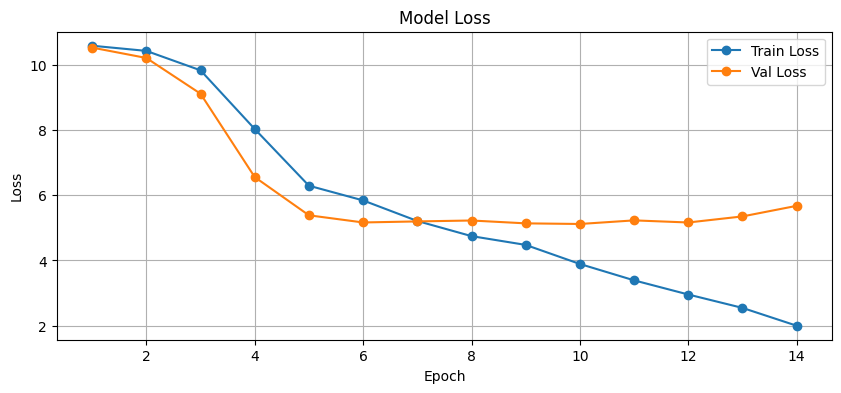

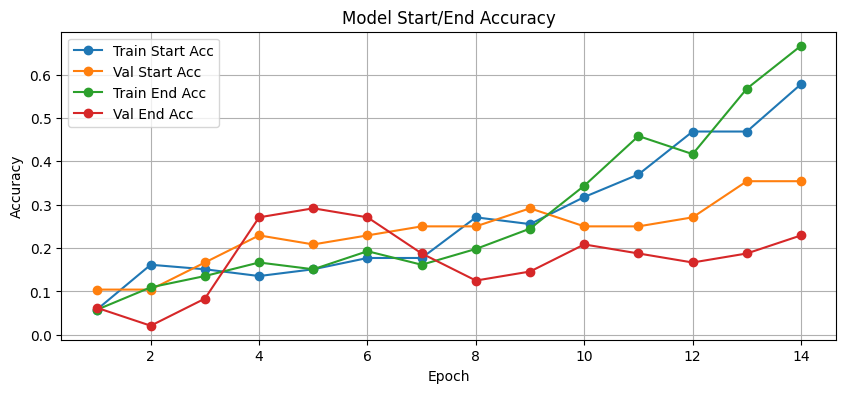

In [561]:
%matplotlib inline
import matplotlib.pyplot as plt

hist = history.history

train_loss = hist.get('loss', [])
val_loss = hist.get('val_loss', [])
train_acc_start = hist.get('start_accuracy', [])
train_acc_end = hist.get('end_accuracy', [])
val_acc_start = hist.get('val_start_accuracy', [])
val_acc_end = hist.get('val_end_accuracy', [])

epochs = range(1, len(train_loss) + 1)

# -------- Loss --------
plt.figure(figsize=(10, 4))
if train_loss:
    plt.plot(epochs, train_loss, marker='o', label='Train Loss')
if val_loss:
    plt.plot(epochs, val_loss, marker='o', label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

# -------- Accuracy (Start/End) --------
plt.figure(figsize=(10, 4))
if train_acc_start:
    plt.plot(epochs, train_acc_start, marker='o', label='Train Start Acc')
if val_acc_start:
    plt.plot(epochs, val_acc_start, marker='o', label='Val Start Acc')
if train_acc_end:
    plt.plot(epochs, train_acc_end, marker='o', label='Train End Acc')
if val_acc_end:
    plt.plot(epochs, val_acc_end, marker='o', label='Val End Acc')
plt.title('Model Start/End Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

In [562]:
import random

def predict_answer(question, context):
    """
    Predict answer span using start/end position probabilities.
    Args:
        question: Question text
        context: Context/passage text
    Returns:
        Predicted answer span
    """
    if 'model' not in globals() or 'tokenizer' not in globals():
        print("يرجى تشغيل خلايا التدريب (model/tokenizer) أولاً.")
        return None

    if not question or not context:
        print("السؤال أو السياق فارغ.")
        return None

    question_clean = normalize_text(question)
    context_clean = normalize_text(context)

    question_encoded = tokenizer.texts_to_sequences([question_clean])
    context_encoded = tokenizer.texts_to_sequences([context_clean])

    question_padded = pad_sequences(question_encoded, maxlen=MAX_Q_LEN, padding='post')
    context_padded = pad_sequences(context_encoded, maxlen=MAX_C_LEN, padding='post')

    # Get probability distributions over positions
    start_probs, end_probs = qa_model.model.predict([question_padded, context_padded], verbose=0)
    
    # Extract argmax positions and confidence
    start_idx = int(np.argmax(start_probs[0]))
    end_idx = int(np.argmax(end_probs[0]))
    start_conf = float(np.max(start_probs[0]))
    end_conf = float(np.max(end_probs[0]))

    # Ensure valid span (end >= start)
    if end_idx < start_idx:
        end_idx = start_idx

    # Decode to text
    context_tokens = context_clean.split()
    # if not context_tokens:
    #     return ("" , 0.0) if return_confidence else ""

    # Clamp to valid range
    start_idx = max(0, min(start_idx, len(context_tokens) - 1))
    end_idx = max(start_idx, min(end_idx, len(context_tokens) - 1))

    predicted_span = " ".join(context_tokens[start_idx:end_idx + 1]).strip()
    
    return predicted_span


# Test with random example from dataset
idx = random.randint(0, len(data) - 1)
sample_item = data[idx]
sample_question = sample_item['question']
sample_context = sample_item['context']
ground_truth_answer = sample_item['answer']

predicted_answer = predict_answer(sample_question, sample_context)

print(f'📌 Example #{idx + 1} from dataset:')
print(f'\n❓ Question: {sample_question}')
print(f'\n📝 Context: {sample_context}')
print(f'\n✅ Ground Truth: {ground_truth_answer}')
print(f'\n🤖 Prediction: {predicted_answer}')
# print(f'\n📊 Confidence: {confidence:.2%}')

📌 Example #65 from dataset:

❓ Question: متي حدث الانفجار الكامبري؟

📝 Context: من حوالي 541 مليون سنه، الحياه كانت بسيطه... فجاه الحياه تنفجر!

✅ Ground Truth: من حوالي 541 مليون سنه

🤖 Prediction: من حوالي 541 مليون سنه،
